In [62]:
#
# Ejemplo de lectura de datos de un ECG y agregado / filtrado de ruido / interferencia de 50 HZ
#
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, iirnotch



In [63]:
# ===============================
# Parámetros
# ===============================
fs = 250        # Frecuencia de muestreo (Hz) AJUSTAR si es necesario
f_notch = 50    # Frecuencia de red (50 o 60 Hz)
Q = 30          # Factor de calidad del notch
noise_amp = 0.4   # Amplitud del ruido 50 Hz
f_noise = 50      # Frecuencia de red (50 Hz)




In [64]:
# ===============================
# Cargar ECG
# ===============================
url = "https://raw.githubusercontent.com/rfurch/unlpam_noise/refs/heads/main/data/ecg_sample_01.csv"
df = pd.read_csv(url)

print(df.head())

#df = pd.read_csv("sample.csv")
ecg = df.iloc[:, 0].values
N = len(ecg)
t = np.arange(N) / fs

   Sample Value
0     -0.001622
1      0.002459
2      0.000177
3     -0.015121
4     -0.038852


In [66]:
# ===============================
# Funciones
# ===============================
def fft_spectrum(x, fs):
    X = np.fft.rfft(x)
    f = np.fft.rfftfreq(len(x), 1/fs)
    return f, np.abs(X)

def notch_filter(x, fs, f0, Q):
    b, a = iirnotch(f0, Q, fs)
    return filtfilt(b, a, x)


In [67]:
# ===============================
# Agregar ruido de 50 Hz
# ===============================
noise_50hz = noise_amp * np.sin(2 * np.pi * f_noise * t)
ecg_noisy = ecg + noise_50hz

In [68]:
# ===============================
# Filtro Notch 50 Hz
# ===============================
b, a = iirnotch(f_noise, Q, fs)
ecg_filtered = filtfilt(b, a, ecg_noisy)

In [69]:
# ===============================
# FFT señal original
# ===============================
f, X = fft_spectrum(ecg, fs)

# ===============================
# Filtro notch
# ===============================
ecg_notch = notch_filter(ecg, fs, f_notch, Q)

# FFT señal + 50 HZ
f3, X3 = fft_spectrum(ecg_noisy, fs)

# FFT señal filtrada
f2, X2 = fft_spectrum(ecg_notch, fs)


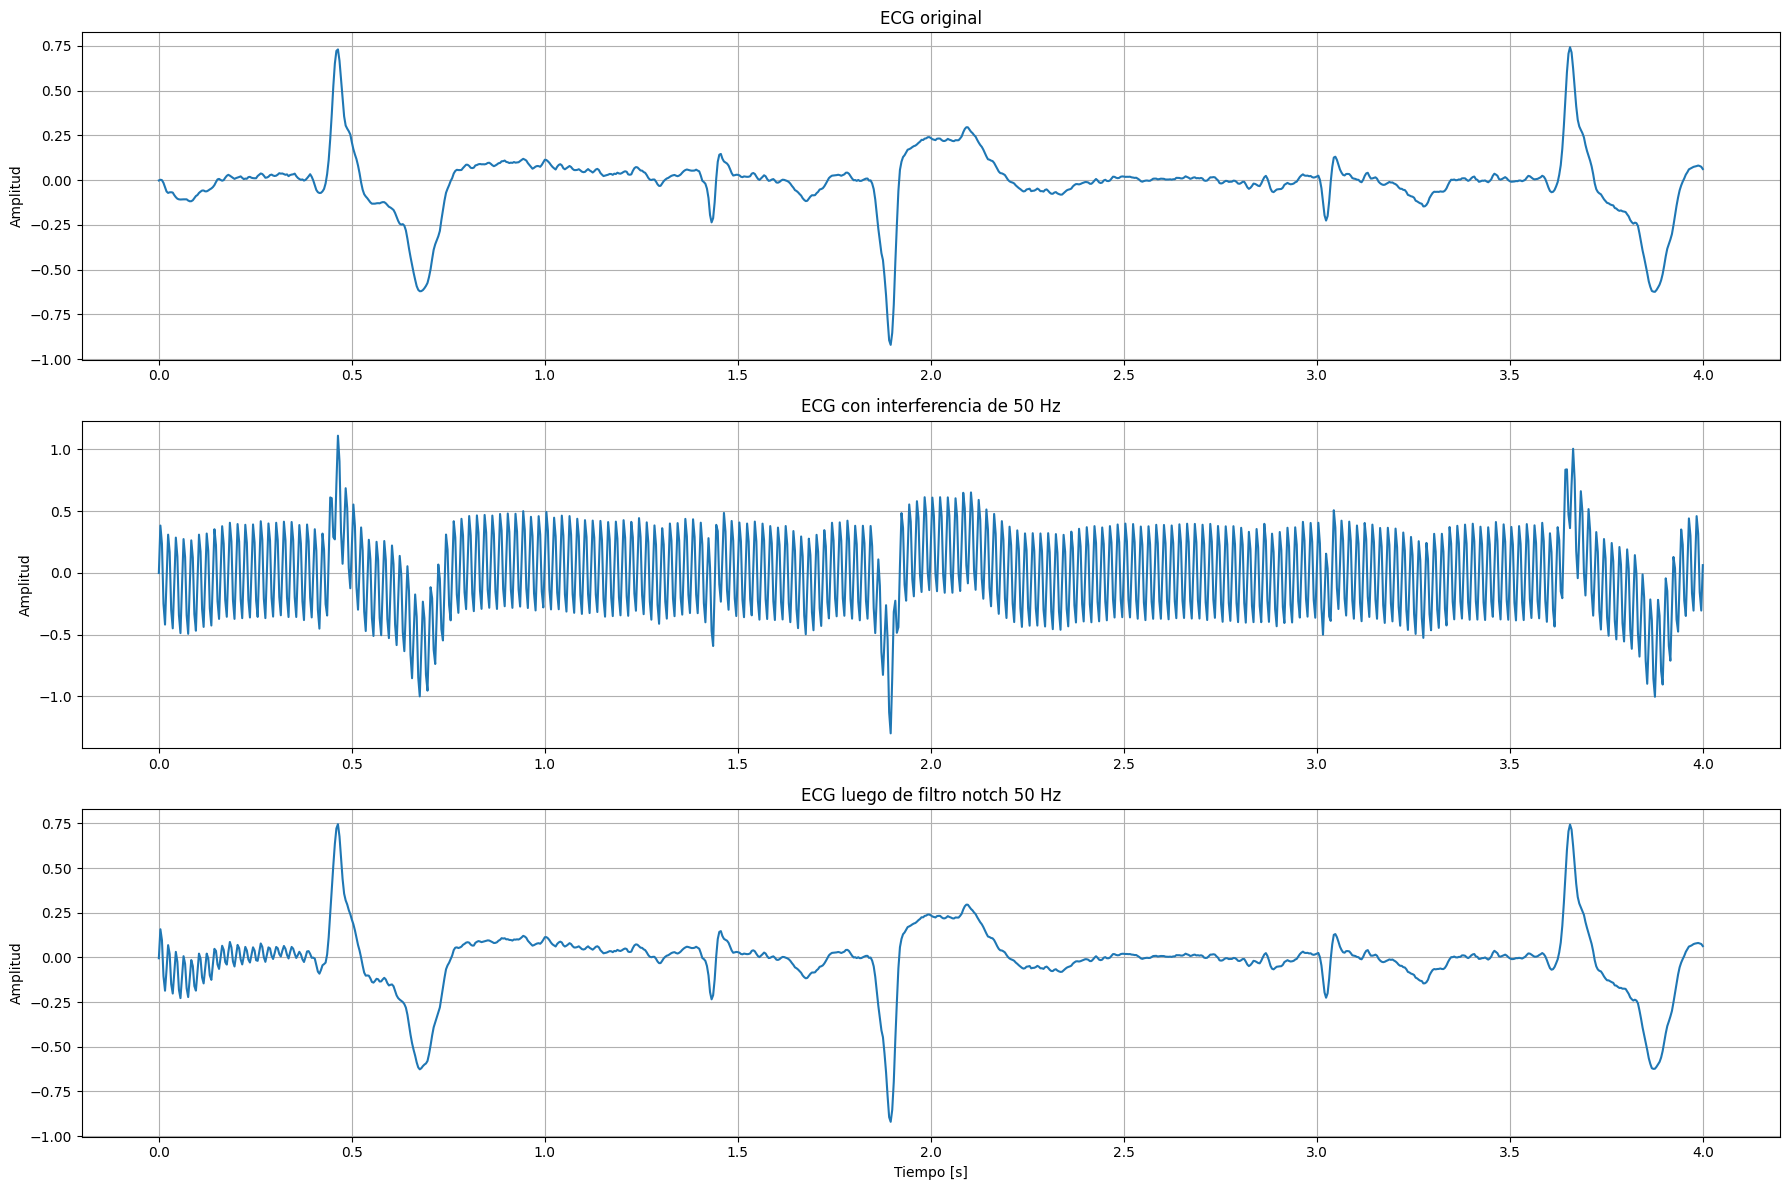

In [70]:
# ===============================
# Gráficas grandes
# ===============================
plt.figure(figsize=(18, 12))

plt.subplot(3, 1, 1)
plt.plot(t, ecg)
plt.title("ECG original")
plt.ylabel("Amplitud")
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(t, ecg_noisy)
plt.title("ECG con interferencia de 50 Hz")
plt.ylabel("Amplitud")
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(t, ecg_filtered)
plt.title("ECG luego de filtro notch 50 Hz")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)

plt.tight_layout()
plt.show()

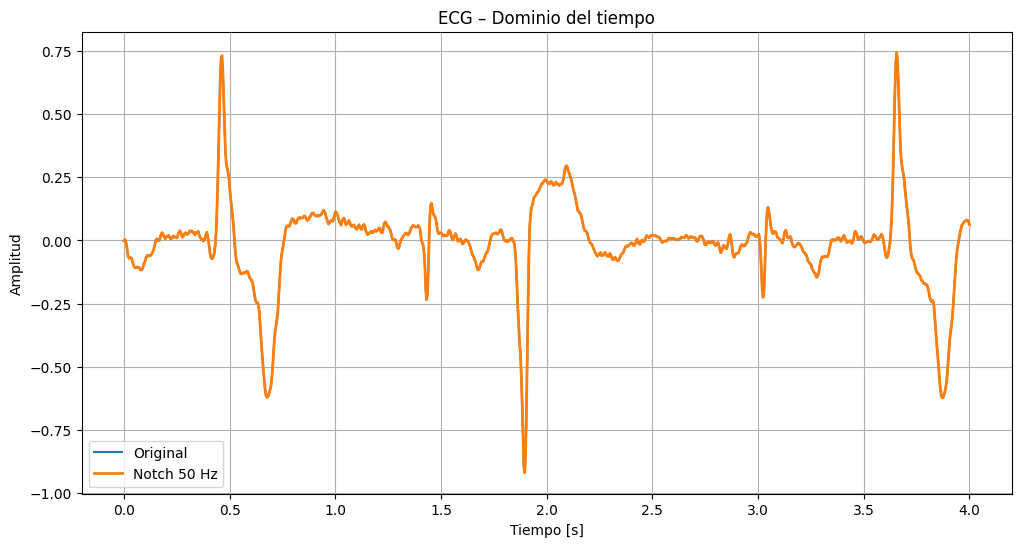

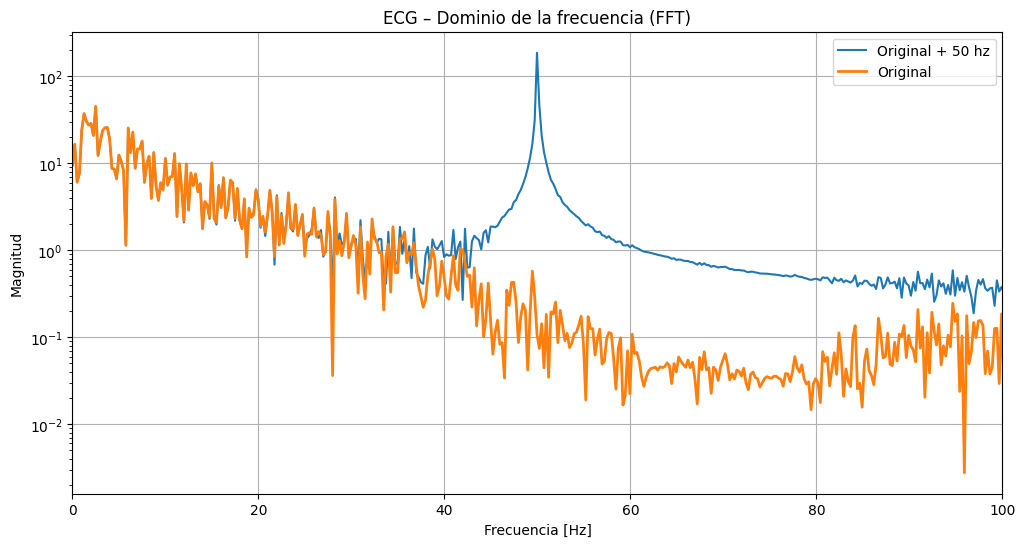

In [71]:
# ===============================
# Gráficas
# ===============================

# ---- Tiempo ----
plt.figure(figsize=(12, 6))
plt.plot(t, ecg, label="Original")
plt.plot(t, ecg_notch, label="Notch 50 Hz", linewidth=2)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("ECG – Dominio del tiempo")
plt.legend()
plt.grid(True)
plt.show()

# ---- Frecuencia ----
plt.figure(figsize=(12, 6))
plt.semilogy(f3, X3, label="Original + 50 hz")
plt.semilogy(f, X, label="Original", linewidth=2)
plt.xlim(0, 100)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.title("ECG – Dominio de la frecuencia (FFT)")
plt.legend()
plt.grid(True)
plt.show()